RAJKUMAR_202501100300198

Case Study: Credit Card Fraud Detection — Apply XGBoost on a heavily imbalanced transactions dataset (e.g. Kaggle IEEE-CIS). Use SMOTE for oversampling, tune decision thresholds, and interpret results with feature importance scores. Compare against a baseline SVM.

Saving creditcard.csv to creditcard (1).csv
First 5 Rows:
            Time        V1        V2        V3        V4        V5        V6  \
0  167595.061255 -0.264799  0.602586 -1.057775 -1.412052  0.531687 -0.069467   
1   29776.873744 -0.187166  1.276264  0.371207  0.018231 -0.019530 -0.713629   
2  120120.978939  0.922181 -1.719689 -0.896341  0.908013  0.097451  0.211875   
3   82922.507189 -2.012349  1.877221  0.692500  0.102803 -0.891360 -0.438067   
4  116069.878265  0.882182  1.536463 -2.583519  0.595709  0.264251  1.027085   

         V7        V8        V9  ...       V21       V22       V23       V24  \
0 -0.002911 -0.797647  0.391177  ... -1.361661 -0.085376 -0.843510  0.567228   
1 -0.543983  0.427376 -1.385361  ...  1.917288  0.829098 -0.741843 -0.381771   
2  0.711384 -0.889601  1.055073  ...  1.398592 -0.421531  1.067802 -0.546425   
3  0.609351  0.632079  0.668393  ... -1.118012 -0.313261  3.158942 -0.261469   
4 -1.125626 -0.506141  0.900537  ...  0.786330 -0.875503  0.7

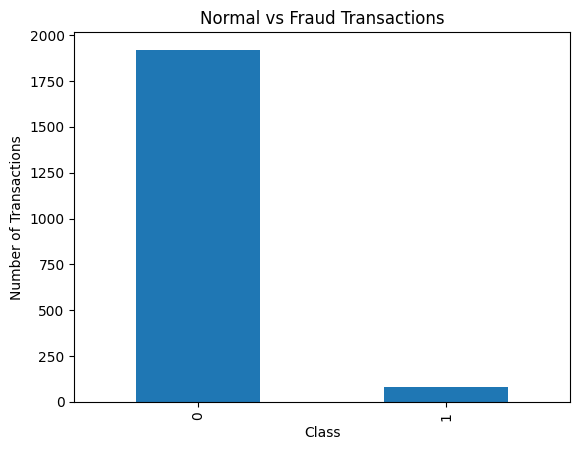


Training Data: (1600, 30)
Testing Data: (400, 30)

Model Training Completed

========== MODEL RESULTS ==========
Accuracy : 0.9875
Precision: 0.8666666666666667
Recall   : 0.8125
F1 Score : 0.8387096774193549
ROC-AUC  : 0.9962565104166666

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       384
           1       0.87      0.81      0.84        16

    accuracy                           0.99       400
   macro avg       0.93      0.90      0.92       400
weighted avg       0.99      0.99      0.99       400


========== CONFUSION MATRIX ==========
[[382   2]
 [  3  13]]


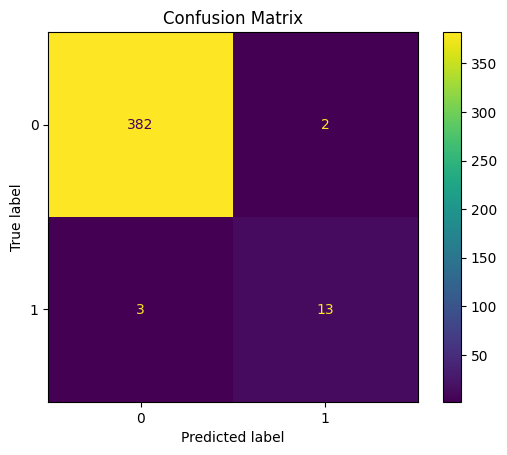

In [3]:
# ============================================
# CREDIT CARD FRAUD DETECTION
# ============================================

# 1. Upload File
from google.colab import files

uploaded = files.upload()


# 2. Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# 3. Load Dataset
data = pd.read_csv("creditcard.csv")

print("First 5 Rows:")
print(data.head())


# 4. Dataset Information
print("\nDataset Shape:")
print(data.shape)

print("\nColumns:")
print(data.columns)

print("\nMissing Values:")
print(data.isnull().sum())


# 5. Check Class Distribution
print("\nClass Distribution:")
print(data["Class"].value_counts())


# 6. Plot Class Distribution
data["Class"].value_counts().plot(kind="bar")

plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.title("Normal vs Fraud Transactions")

plt.show()


# 7. X and y
X = data.drop("Class", axis=1)

y = data["Class"]


# 8. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)


# 9. Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)


# 10. Create Logistic Regression Model
model = LogisticRegression(
    max_iter=1000
)


# 11. Train Model
model.fit(X_train, y_train)

print("\nModel Training Completed")


# 12. Prediction
y_pred = model.predict(X_test)


# 13. Probability Prediction
y_probability = model.predict_proba(X_test)[:, 1]


# 14. Evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probability)


# 15. Display Results
print("\n========== MODEL RESULTS ==========")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)


# 16. Classification Report
print("\n========== CLASSIFICATION REPORT ==========")

print(classification_report(y_test, y_pred))


# 17. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\n========== CONFUSION MATRIX ==========")

print(cm)


# 18. Confusion Matrix Plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Confusion Matrix")

plt.show()